<a href="https://colab.research.google.com/github/mokhivibes/ml_course_hometasks/blob/main/7_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [99]:
!pip install opendatasets

In [100]:
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
od.download("https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset/data")


Skipping, found downloaded files in "./car-price-prediction-dataset" (use force=True to force download)


In [102]:
df=pd.read_csv("/content/car-price-prediction-dataset/cardekho.csv")

In [103]:
df.shape

(8128, 12)

In [104]:
df.head(20)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,5.0
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,Manual,First Owner,17.30,1061.0,57.5,5.0
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.10,796.0,37,4.0
8,Toyota Etios VXD,2011,350000,90000,Diesel,Individual,Manual,First Owner,23.59,1364.0,67.1,5.0
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Individual,Manual,First Owner,20.00,1399.0,68.1,5.0


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [106]:
print(df.isnull().sum().sum())
print(df.duplicated().sum().sum())

878
1202


In [107]:
df['max_power'] = df['max_power'].astype(str).str.extract(r'([\d.])')[0]
df['max_power'] = pd.to_numeric(df['max_power'], errors="coerce")

num_cols= df.select_dtypes(include="number").columns

for col in num_cols:
  print(f"{col}: {(df[col].duplicated().sum()/ len(df) * 100).round(2)}")

print("\n")
for col in num_cols:
  print(f"{col}: {(df[col].isnull().sum()/ len(df) * 100).round(2)}")

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

#String/object columns
print("\n")

cat_cols= df.select_dtypes(include="object").columns
for col in cat_cols:
  print(f"{col}: {(df[col].duplicated().sum()/ len(df) * 100).round(2)}")

print("\n")
for col in cat_cols:
  print(f"{col}: {(df[col].isnull().sum()/ len(df) * 100).round(2)}")

df[cat_cols] = df[cat_cols].fillna("None")

#Question: if there are a lot of duplicated value on the columns can we delete them?


year: 99.64
selling_price: 91.67
km_driven: 88.67
mileage(km/ltr/kg): 95.3
engine: 98.5
max_power: 99.86
seats: 99.88


year: 0.0
selling_price: 0.0
km_driven: 0.0
mileage(km/ltr/kg): 2.72
engine: 2.72
max_power: 2.66
seats: 2.72


name: 74.68
fuel: 99.95
seller_type: 99.96
transmission: 99.98
owner: 99.94


name: 0.0
fuel: 0.0
seller_type: 0.0
transmission: 0.0
owner: 0.0


In [108]:
sns.set_theme(context='notebook', style='darkgrid', palette='tab10', font='DejaVu Sans', font_scale=1.2, color_codes=True,   rc={"figure.figsize": (10, 5),
"axes.titlecolor": "#8263CA", "text.color":"#8263CA", "xtick.color": "#8263CA",
"ytick.color": "#8263CA", "axes.labelcolor": "#8263CA", "axes.titleweight": "bold", "axes.labelweight": "bold",  "font.weight": "bold"})


In [109]:
# print(num_cols)
# for col in df[num_cols]:
#   sns.histplot(df[col], color ="#42DE3F", kde=True)
#   plt.title(col)
#   plt.tight_layout()
#   plt.show()
#   print("\n")

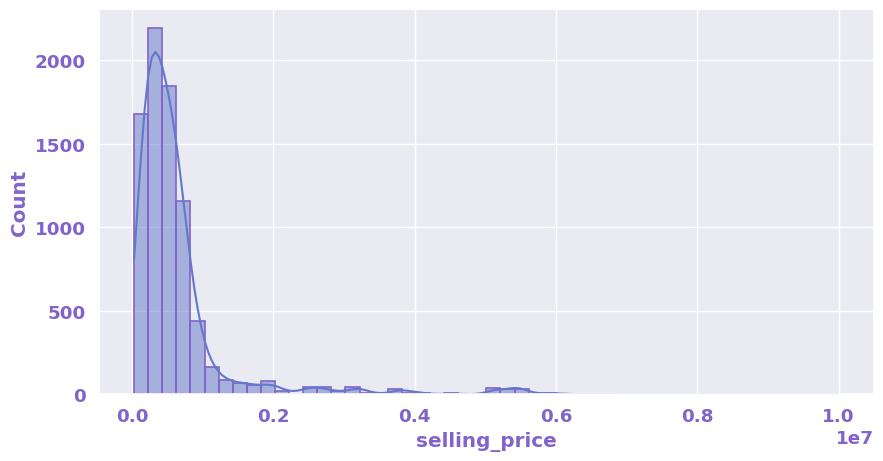

In [110]:
sns.histplot(df['selling_price'], color='#6378CA', kde=True, edgecolor = '#8263CA', linewidth=1.2, bins=50)
plt.show()

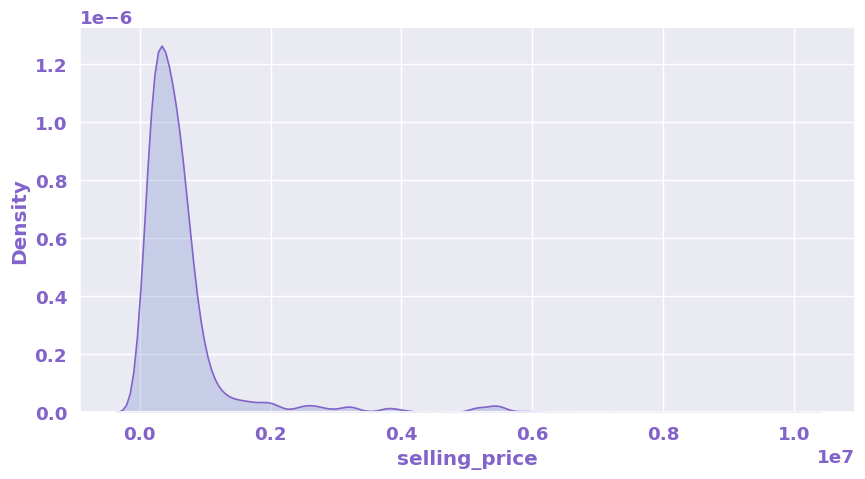

In [111]:
sns.kdeplot(df['selling_price'], fill=True, color='#6378CA', edgecolor = '#8263CA', linewidth=1.2)
plt.show()

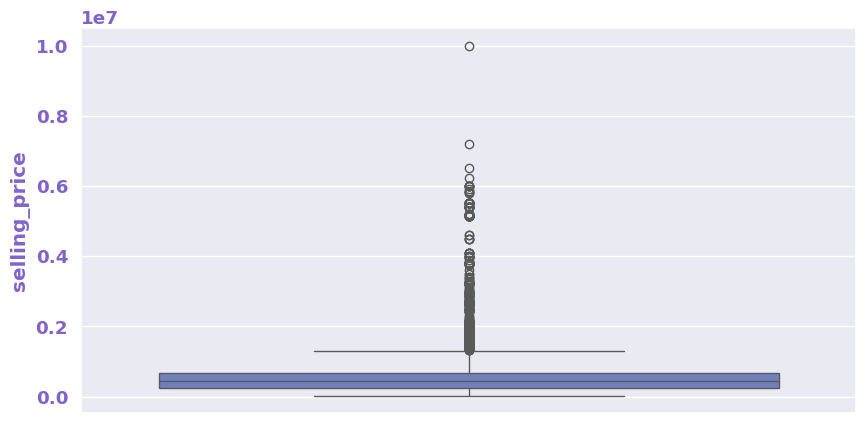

In [112]:
sns.boxplot(df["selling_price"],color='#6378CA')
plt.show()

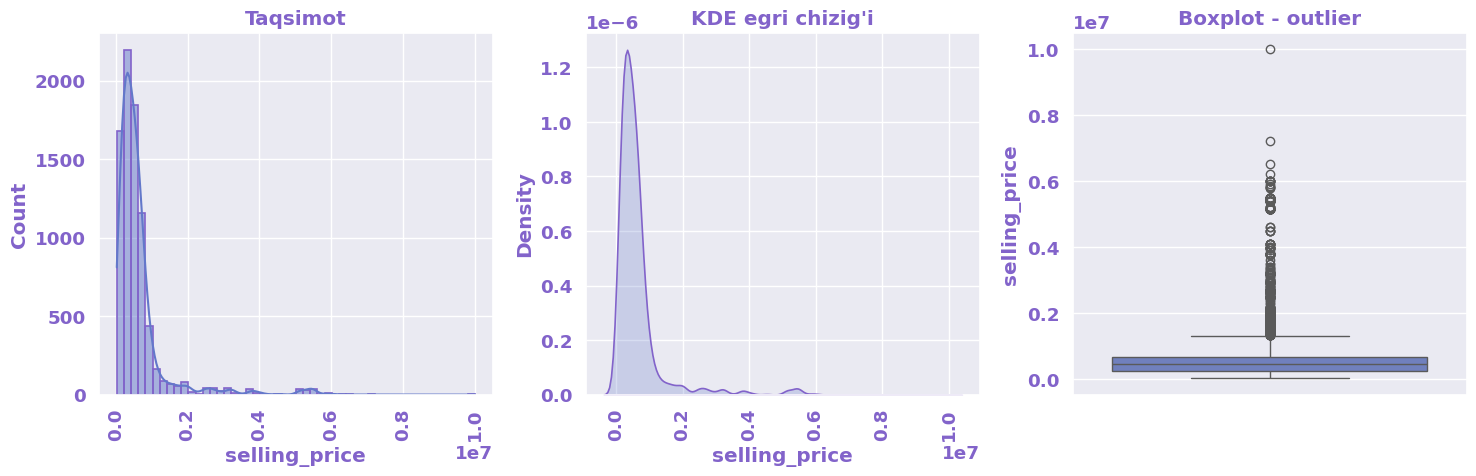

In [113]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#1. Histogram
sns.histplot(df['selling_price'],ax=axes[0], color='#6378CA', kde=True, edgecolor = '#8263CA', linewidth=1.2, bins=50)
axes[0].set_title('Taqsimot')
axes[0].tick_params(axis='x', rotation=90)


#2. KDE
sns.kdeplot(df['selling_price'], fill=True, ax=axes[1], color='#6378CA', edgecolor = '#8263CA', linewidth=1.2)
axes[1].set_title('KDE egri chizig\'i')
axes[1].tick_params(axis='x', rotation=90)

#3. Box Plot
sns.boxplot(df["selling_price"], ax=axes[2], color='#6378CA')
axes[2].set_title('Boxplot - outlier')

plt.tight_layout()
plt.show()

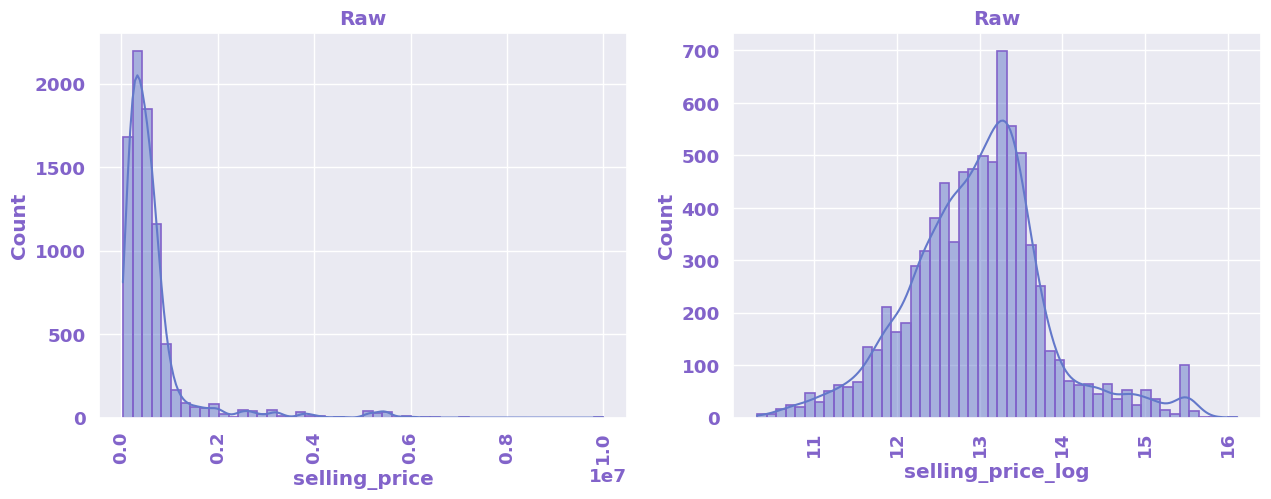

In [114]:
df['selling_price_log']= np.log1p(df['selling_price'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['selling_price'], color='#6378CA', ax=axes[0], kde=True, edgecolor = '#8263CA', linewidth=1.2, bins=50)
axes[0].set_title('Raw')
axes[0].tick_params(axis='x', rotation=90)

sns.histplot(df['selling_price_log'], color='#6378CA', ax=axes[1], kde=True, edgecolor = '#8263CA', linewidth=1.2, bins=50)
axes[1].set_title('Raw')
axes[1].tick_params(axis='x', rotation=90)


                        year  selling_price  km_driven  mileage(km/ltr/kg)  \
year                1.000000       0.414092  -0.418006            0.310383   
selling_price       0.414092       1.000000  -0.225534           -0.125454   
km_driven          -0.418006      -0.225534   1.000000           -0.171426   
mileage(km/ltr/kg)  0.310383      -0.125454  -0.171426            1.000000   
engine              0.017773       0.453567   0.203954           -0.575831   
max_power           0.073347      -0.360579  -0.064473            0.471891   
seats              -0.008623       0.041161   0.225172           -0.452085   

                      engine  max_power     seats  
year                0.017773   0.073347 -0.008623  
selling_price       0.453567  -0.360579  0.041161  
km_driven           0.203954  -0.064473  0.225172  
mileage(km/ltr/kg) -0.575831   0.471891 -0.452085  
engine              1.000000  -0.493303  0.610309  
max_power          -0.493303   1.000000 -0.260873  
seats      

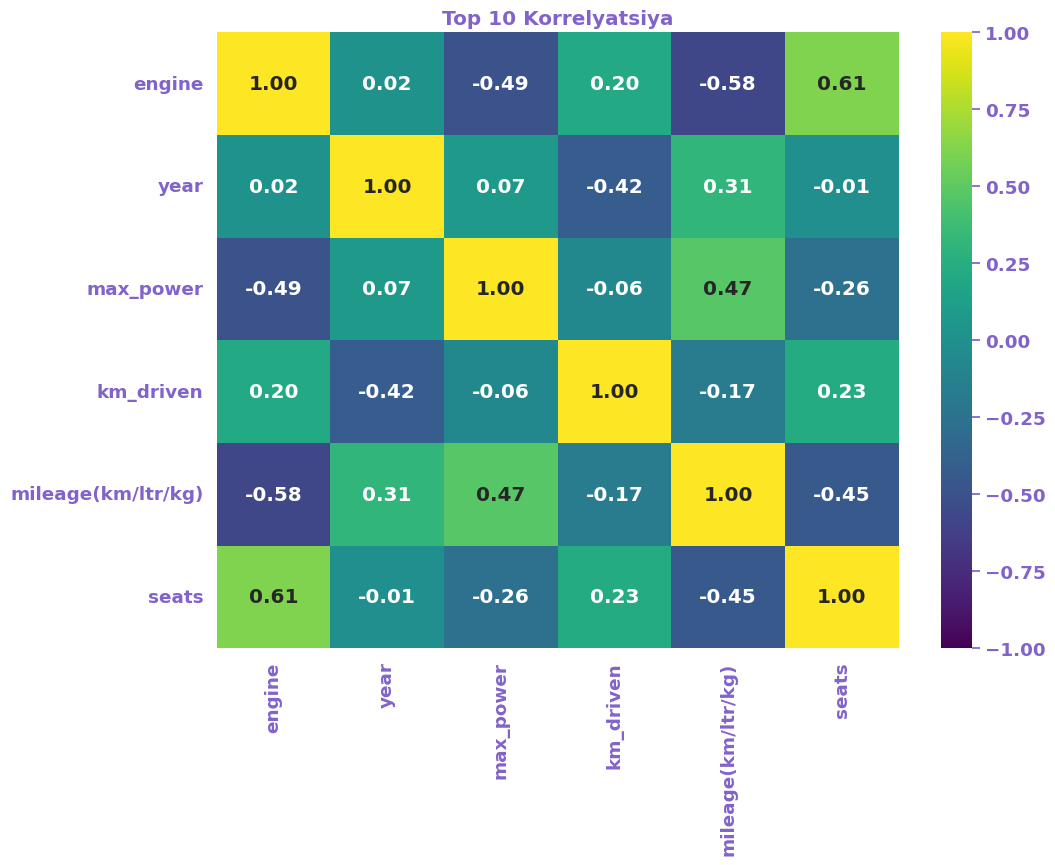

In [115]:
corr= df[num_cols].corr()
print(corr)
#TOp 10 SalePrice bilan
top10=corr['selling_price'].drop('selling_price').abs().sort_values(ascending=False).index
print(top10)
# top_cols=list(top10)+['SalePrice']

# #HeatMap

plt.figure(figsize=(11,8))

sns.heatmap(
    corr[top10].loc[top10], annot=True, fmt='.2f' ,
    cmap='viridis', center=0, vmax=1, vmin=-1
)
plt.title('Top 10 Korrelyatsiya')
plt.show()

/tmp/ipykernel_39704/1079017240.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_39704/1079017240.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 75.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

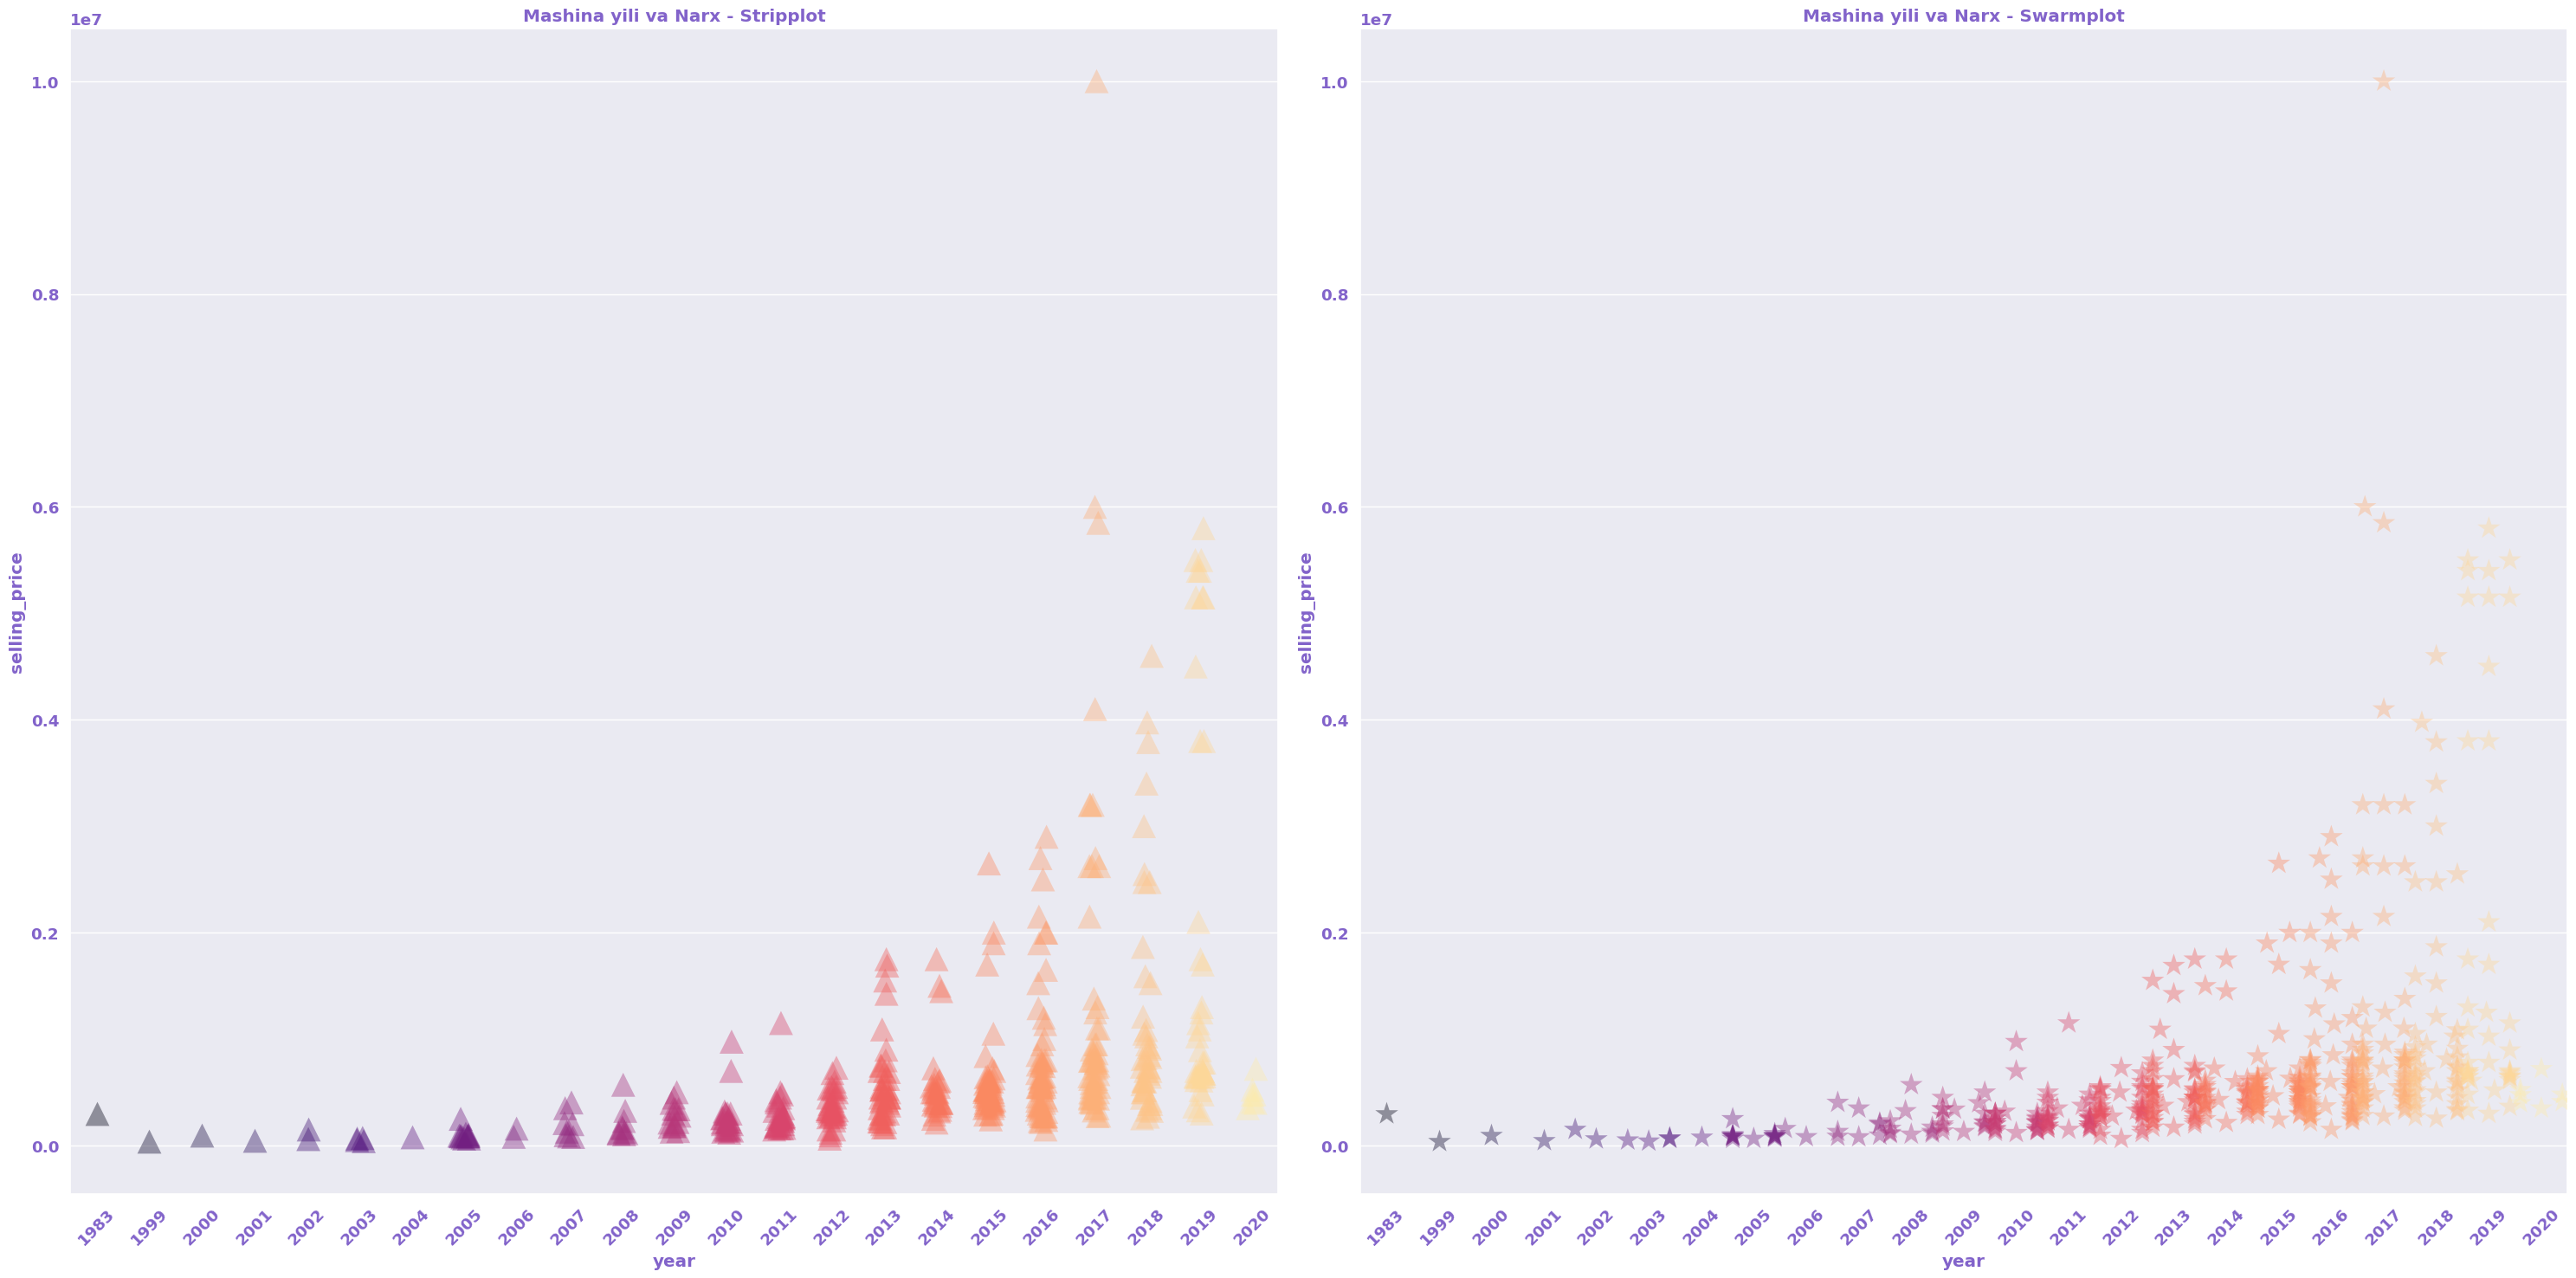

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(30, 15))
top10df = df.head(500)
sns.stripplot(
    data=top10df, x='year', y='selling_price', alpha=0.4, marker='^',
    palette='magma', ax=axes[0], s=20
)



axes[0].set_title('Mashina yili va Narx - Stripplot')

sns.swarmplot(
    data=top10df, x='year', y='selling_price', alpha=0.4, marker='*',
    palette='magma', ax=axes[1], s=20
)
axes[0].tick_params(axis='x', rotation=45)


axes[1].set_title('Mashina yili va Narx - Swarmplot')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

fuel
Diesel    791452.921627
Petrol    462441.061691
CNG       301017.491228
LPG       200421.052632
Name: selling_price, dtype: float64


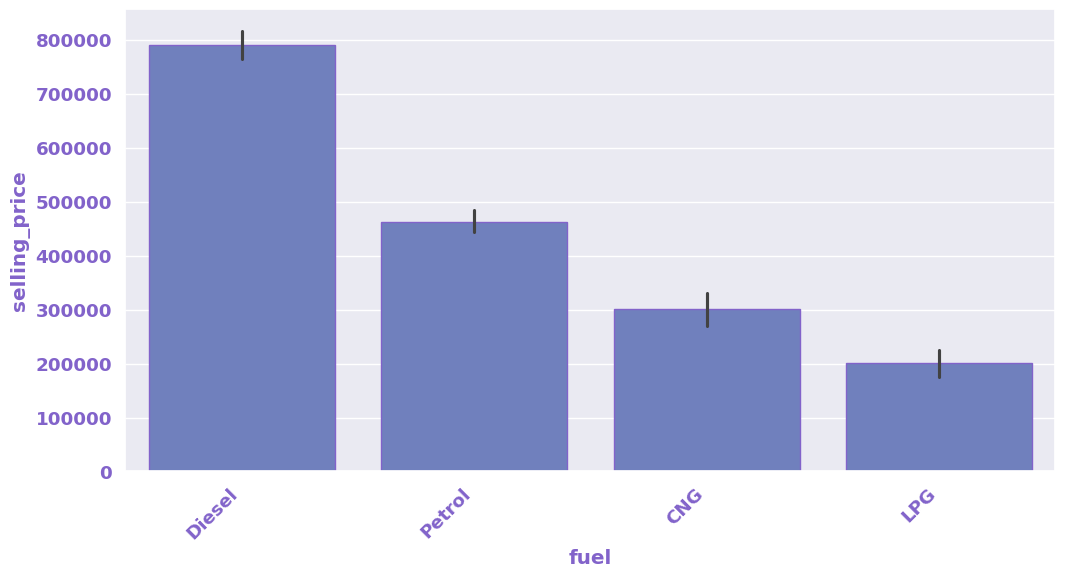

In [119]:
hood=df.groupby('fuel')['selling_price'].mean().sort_values(ascending=False)

print(hood)

plt.figure(figsize=(12,6))

sns.barplot(data=df, x='fuel', y='selling_price',
            order=hood.index, color='#6378CA', width=0.8, edgecolor="#8263CA")
plt.xticks(rotation=45, ha='right')
plt.show()

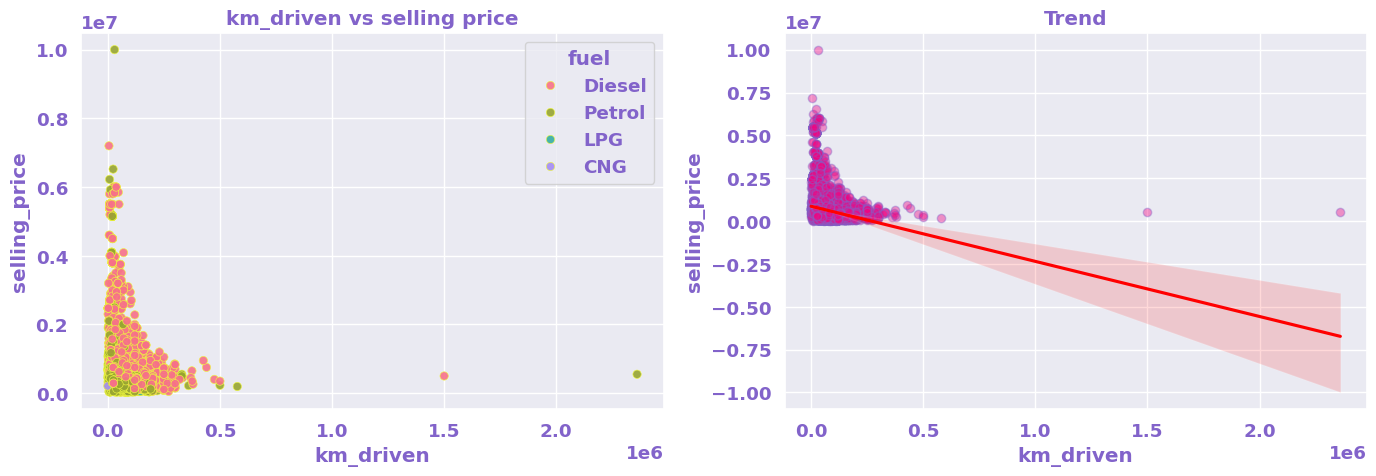

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df, x='km_driven', y='selling_price',
    hue='fuel',
    palette='husl' , ax=axes[0],alpha=0.9, edgecolor='#EEF740'
)

axes[0].set_title('km_driven vs selling price')

sns.regplot(
    data=df, x='km_driven', y='selling_price',
    scatter_kws = {"alpha":0.4, 'color': '#F00582', 'edgecolor': '#8263CA'},
    line_kws={'color':'red'}, ax=axes[1]
)
axes[1].set_title('Trend')

plt.tight_layout()
plt.show()